# 05 — Learning-Rate Schedule Ablation

**Hypothesis**: A decaying learning rate lets the model make large moves early
and refine late. Warmup can prevent early instability with softmin losses.
Plateau-reduce can adapt automatically to training plateaus.

**Experiment**: Fix Power-SM3 τ=0.12. Compare 4 schedules:
- `none` — constant lr=3e-4
- `cosine` — CosineAnnealingLR(T_max=N_EPOCHS)
- `warmup_cosine` — linear warmup 5 epochs then cosine (LambdaLR)
- `plateau` — ReduceLROnPlateau(patience=5, factor=0.5)


In [1]:
import sys
sys.path.insert(0, '.')
import clevr_utils as cu
import torch
from influencerformer.losses import PowerSoftMinLoss
print(f'Device: {cu.DEVICE}')


Device: cuda


In [2]:
N_EPOCHS = 50
SNAPSHOT_EPOCHS = {0, 5, 15, 35, 49}
TAU = 0.12
WARMUP = 5


def make_warmup_cosine(optimizer, warmup_epochs=WARMUP, total_epochs=N_EPOCHS):
    '''LambdaLR with linear warmup then cosine annealing.

    Args:
        optimizer: torch optimizer
        warmup_epochs: number of linear warmup epochs
        total_epochs: total training epochs
    Returns:
        LambdaLR scheduler
    '''
    import math

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


scheduler_fns = {
    'none':          None,
    'cosine':        lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS),
    'warmup_cosine': lambda opt: make_warmup_cosine(opt),
    'plateau':       lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5),
}


In [3]:
all_results = {}
for name, sched_fn in scheduler_fns.items():
    print(f'=== {name} ===')
    metrics, snapshots = cu.train_and_monitor(
        PowerSoftMinLoss(temperature=TAU, power=3.0),
        name,
        scheduler_fn=sched_fn,
        n_epochs=N_EPOCHS,
        snapshot_epochs=SNAPSHOT_EPOCHS,
        tau_for_entropy=TAU,
    )
    all_results[name] = (metrics, snapshots)


=== none ===


/global/homes/d/danieltm/.conda/envs/influencer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:296: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343970094/work/aten/src/ATen/NestedTensorImpl.cpp:177.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


  [none] epoch   0 | loss=10.5985 dist=1.6252 div=1.487 H=0.224 gd=0.739 lr=3.00e-04
  [none] epoch   1 | loss=6.9616 dist=1.5249 div=1.538 H=0.204 gd=0.591 lr=3.00e-04
  [none] epoch   2 | loss=5.6338 dist=1.4429 div=1.611 H=0.211 gd=0.575 lr=3.00e-04
  [none] epoch   3 | loss=4.6823 dist=1.3842 div=1.708 H=0.204 gd=0.532 lr=3.00e-04
  [none] epoch   4 | loss=4.0530 dist=1.3388 div=1.774 H=0.197 gd=0.676 lr=3.00e-04
  [none] epoch   5 | loss=3.6125 dist=1.3050 div=1.798 H=0.195 gd=0.659 lr=3.00e-04
  [none] epoch   6 | loss=3.2976 dist=1.2851 div=1.823 H=0.190 gd=0.495 lr=3.00e-04
  [none] epoch   7 | loss=3.0575 dist=1.2619 div=1.862 H=0.188 gd=0.562 lr=3.00e-04
  [none] epoch   8 | loss=2.8828 dist=1.2413 div=1.869 H=0.185 gd=0.526 lr=3.00e-04
  [none] epoch   9 | loss=2.7403 dist=1.2224 div=1.919 H=0.180 gd=0.565 lr=3.00e-04
  [none] epoch  10 | loss=2.6335 dist=1.2117 div=1.912 H=0.180 gd=0.520 lr=3.00e-04
  [none] epoch  11 | loss=2.5524 dist=1.1984 div=1.928 H=0.175 gd=0.473 lr=

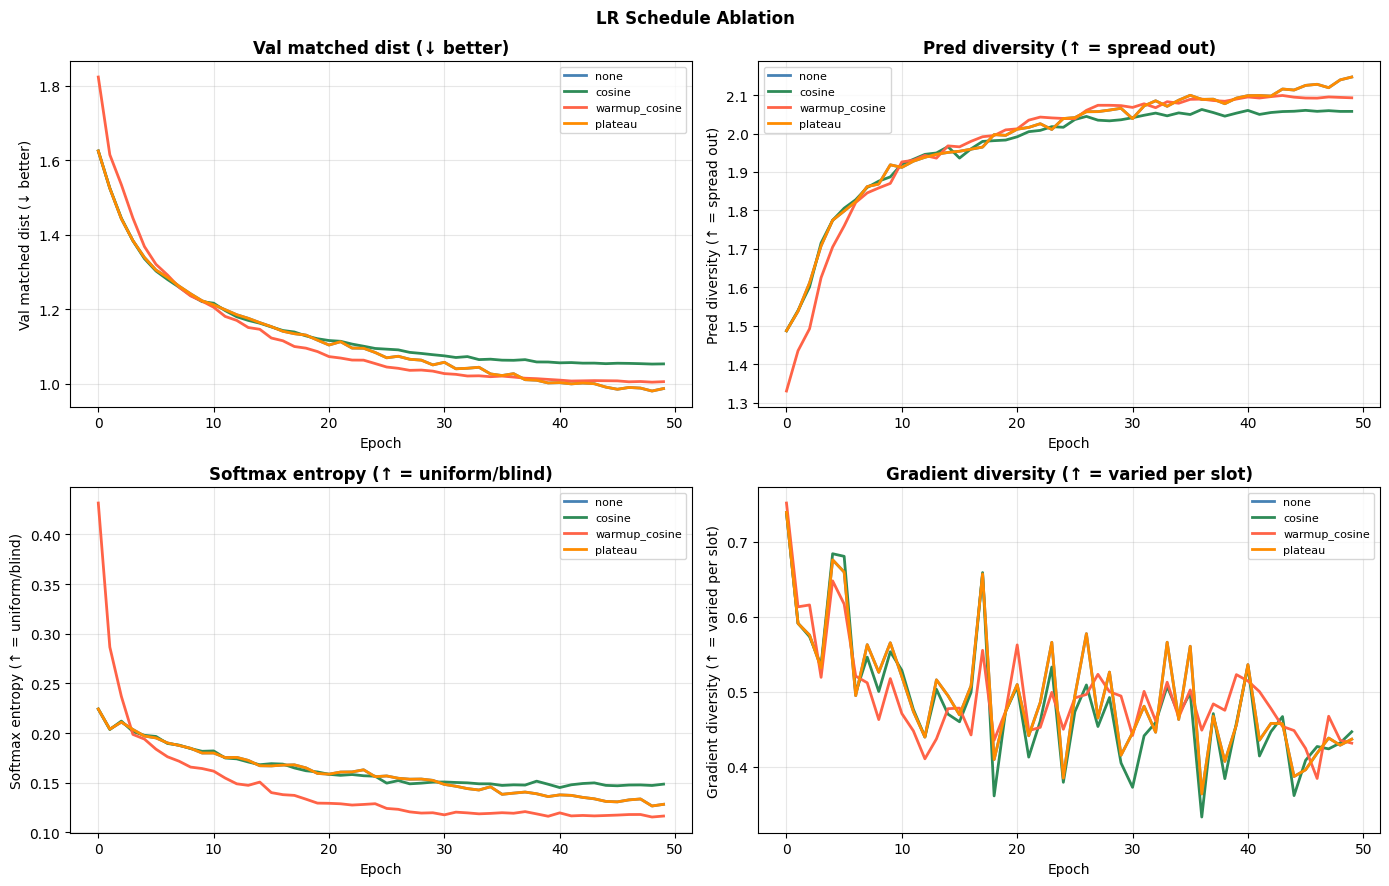

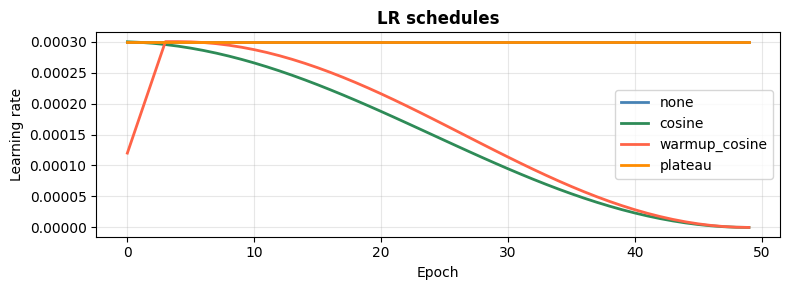

In [4]:
import matplotlib.pyplot as plt

cu.plot_monitoring(all_results, title='LR Schedule Ablation')

# Plot learning rate curves
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']
for (name, (m, _)), color in zip(all_results.items(), colors):
    ax.plot(m['epoch'], m['lr'], label=name, color=color, lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('LR schedules', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
cu.summary_table(all_results)


Name                           Final dist   Pred div   SM entropy   Grad div
----------------------------------------------------------------------------
none                               0.9865     2.1469       0.1283     0.4365
plateau                            0.9865     2.1469       0.1283     0.4365
warmup_cosine                      1.0050     2.0929       0.1165     0.4312
cosine                             1.0528     2.0575       0.1486     0.4464
